# NLP - Embeddings, RNNs and LSTMs 


## Basic Assignment


The notebook will help you practice Many-to-One RNN architecture, as well as Many-to-Many architectures.

The advanced part is included in a different notebook also available in Canvas.


**Authors**: 
- Ariful Islam Riane : 3981886
- Pedro Fernandez Tonso : 3983781
- Group Number : 19

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
import numpy as np
import re
from matplotlib import pyplot as plt
from nltk.corpus import treebank
from gensim.models import KeyedVectors
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import pandas as pd
import nltk
import tensorflow as tf

In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

I0000 00:00:1790704347.549374 4093226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790704347.549783 4093226 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790704347.586912 4093226 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790704348.431404 4093226 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790704348.431711 4093226 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Loading the dataset
We will work on a binary classification problem. The dataset is of two classes SPAM and NOT SPAM. 

In [2]:
from pathlib import Path

data_path = Path.cwd() / "lab-1-dt-adv" / "databank" / "spam.csv"
print(data_path)
dataset = pd.read_csv(data_path, encoding='ISO-8859-1')

Num GPUs Available:  0


E0000 00:00:1790704348.568153 4093226 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
X=dataset.v2
X.head()

/home/tonso/code/ptonso/learn/course/ut/ds-ai/lab-1-dt-adv/databank/spam.csv


In [4]:
y=dataset.v1
y.head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: v2, dtype: str

### Exercise 1
Reuse your to_lower(X) function from the NLP basic lab, and the clean_text(X) function to lower case all documents in the dataset and then remove all numerical and special characters from the dataset.


In [5]:
def to_lower(X): 
    X = X.str.lower()
    return X

def clean_text(X):
    X = X.str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    X = X.str.replace(r'\s+', ' ', regex=True)
    X = X.str.strip()
    return X

0     ham
1     ham
2    spam
3     ham
4     ham
Name: v1, dtype: str

In [6]:
X=to_lower(X)
X=clean_text(X)

In [7]:
X

### Exercise 2 
Create the ground truth vector **y** for the binary classification.
Check that the **y** vector is of shape(ne,1).

In [8]:
y = (y=='spam').astype(int)

0       go until jurong point crazy available only in ...
1                                 ok lar joking wif u oni
2       free entry in a wkly comp to win fa cup final ...
3             u dun say so early hor u c already then say
4       nah i don t think he goes to usf he lives arou...
                              ...                        
5567    this is the nd time we have tried contact u u ...
5568                    will b going to esplanade fr home
5569    pity was in mood for that so any other suggest...
5570    the guy did some bitching but i acted like i d...
5571                            rofl its true to its name
Name: v2, Length: 5572, dtype: str

In [9]:
y

### Exercise 3
Use Keras' Tokenizer class to vectorize the corpus. 
What we expect here is that the tokens will be encoded as integers.


Notice that tokenizing here is different from the tokenization process discussed in the basic lecture.

In [10]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X)
X_encoded = tokenizer.texts_to_sequences(X)
vocab_size = len(tokenizer.word_index) + 1

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: v1, Length: 5572, dtype: int64

In [11]:
i=25
print(X[i])
print(X_encoded[i])

### Exercise 4
Whether we work with an RNN cell, an LSTM or a GRU cell, we want first to know how many times should we unroll the network. This will be referred to as 'time_steps'.


In this exercise, the goal is to check the lengths of our documents, and then choose a fixed length for all our documents. 

Documents which are shorter than the length you fixed will be padded with 0s.

Documents which are longer will be truncated. 


a. Check the length of the largest document in the corpus

In [12]:
lengths = [len(doc) for doc in X_encoded]
print("Longest document has", max(lengths), "words")

just forced myself to eat a slice i m really not hungry tho this sucks mark is getting worried he knows i m sick when i turn down pizza lol
[40, 3922, 969, 3, 335, 4, 2731, 1, 26, 163, 28, 761, 637, 41, 1258, 1145, 9, 262, 970, 63, 971, 1, 26, 1048, 46, 1, 1811, 242, 1146, 183]


b. Check the average count of words in all documents

In [13]:
print("Average word count in our documents is", int(sum(lengths)/len(lengths)))

Longest document has 190 words


Quite a distance between the average length and longest document. It's probably worth it to check the lengths in a box plot.

In [14]:
plt.boxplot(lengths, vert=False)
plt.xlabel("document length (words)")
plt.title("Distribution of document lengths")
plt.show()

Average word count in our documents is 15


### Exercise 5

Hopefully, you have chosen a value for the max doc length (which will serve as your time_steps value when you build your RNN).

We can now proceed to use the pad_sequences() method of Keras to pad our sequences, check [here](https://www.tensorflow.org/api_docs/python/tf/keras/utils/pad_sequences).

Sentences longer than **n** will be truncated (you can choose to keep the first **n** words or the last).
Sentences shorter than **n** will be padded with 0.

/tmp/ipykernel_4093226/4135357552.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(lengths, vert=False)


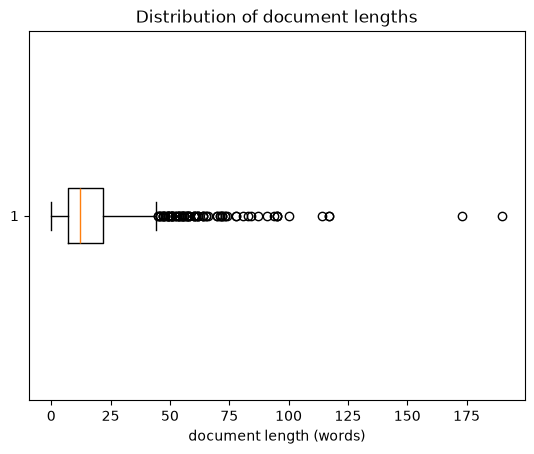

In [15]:
max_len = 30
X_padded = pad_sequences(X_encoded, maxlen=max_len, padding='post', truncating='post')

In [16]:
i=5214
print(X[i])
print(X_encoded[i])
print(X_padded[i])
print(y[i])

### Exercise 6

We can now proceed to pass our padded sequences and our **y** vector to an RNN model for training.
Let's first define a simple RNN model.

In [17]:
# split entire data into training and testing sets
TEST_SIZE = 0.25
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=TEST_SIZE, random_state=100)

natalja f is inviting you to be her friend reply yes or no see her www sms ac u nat stop send stop frnd to
[3828, 705, 9, 1430, 2, 3, 34, 106, 257, 96, 140, 29, 39, 91, 106, 144, 235, 860, 6, 1799, 86, 70, 86, 706, 3]
[3828  705    9 1430    2    3   34  106  257   96  140   29   39   91
  106  144  235  860    6 1799   86   70   86  706    3    0    0    0
    0    0]
1


**Do check the size of the vocab, needed for the rest of the exercises.**

This dataset was chosen particularly for its small vocab size.

In [18]:
print("Vocab size:", vocab_size)

### Exercise7

Let's first try a classification task using basic RNN cells.

You're free to define the number of units and layers as you see fit.

a. Define the architecture of your model and print its summary.

In [19]:
embedding_dim = 32

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model.summary()

Vocab size: 7709


b. Compile your model. 

Use the loss function and the optimizer you want, you don't have to use binary_cross entropy and stochastic gradient descent.

In [20]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

/home/tonso/code/ptonso/learn/course/ut/ds-ai/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 32)         │       246,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,801 (971.88 KB)

 Trainable params: 248,801 (971.88 KB)

 Non-trainable params: 0 (0.00 B)

c. Train your model

In [21]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [22]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.ylim(0,1)
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 2s - 14ms/step - acc: 0.9203 - loss: 0.2565 - val_acc: 0.9734 - val_loss: 0.1005


Epoch 2/10


131/131 - 1s - 6ms/step - acc: 0.9512 - loss: 0.1885 - val_acc: 0.9821 - val_loss: 0.0859


Epoch 3/10


...

131/131 - 1s - 6ms/step - acc: 0.9959 - loss: 0.0240 - val_acc: 0.9835 - val_loss: 0.0533


Epoch 9/10


131/131 - 1s - 7ms/step - acc: 0.9978 - loss: 0.0127 - val_acc: 0.9871 - val_loss: 0.0566


Epoch 10/10


131/131 - 1s - 6ms/step - acc: 0.9981 - loss: 0.0091 - val_acc: 0.9813 - val_loss: 0.0761


The SimpleRNN reaches about 98% test accuracy (always predicting ham gives 86.6%). Training is unstable, with test accuracy dropping to 92% at epoch 6, and it overfits: train accuracy reaches 99.8% while the test loss stops improving after epoch 2.

### Exercise 8
Try to perform the same classification task using an LSTM architecture.

a. Define the architecture of your model and print its summary.

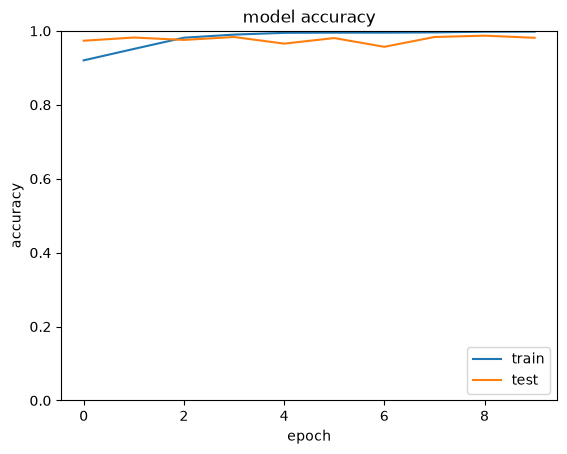

In [23]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
model.summary()

b. compile your model.

In [24]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 32)         │       246,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,041 (996.25 KB)

 Trainable params: 255,041 (996.25 KB)

 Non-trainable params: 0 (0.00 B)

c. Train your model.

In [25]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [26]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 2s - 16ms/step - acc: 0.9088 - loss: 0.2586 - val_acc: 0.9756 - val_loss: 0.0857


Epoch 2/10


131/131 - 1s - 8ms/step - acc: 0.9859 - loss: 0.0598 - val_acc: 0.9878 - val_loss: 0.0468


Epoch 3/10


...

131/131 - 1s - 9ms/step - acc: 0.9993 - loss: 0.0038 - val_acc: 0.9835 - val_loss: 0.0666


Epoch 9/10


131/131 - 1s - 8ms/step - acc: 0.9998 - loss: 0.0012 - val_acc: 0.9842 - val_loss: 0.0736


Epoch 10/10


131/131 - 1s - 9ms/step - acc: 0.9998 - loss: 8.8271e-04 - val_acc: 0.9842 - val_loss: 0.0747


The LSTM ends at 98.5% test accuracy. It overfits as well (train accuracy ~100%, test loss rising after epoch 2), so early stopping after 2 to 4 epochs would be enough.

### Exercise 9

Let's now see whether we get different results using a GRU cell.

a. Define the architecture of your model and print its summary.

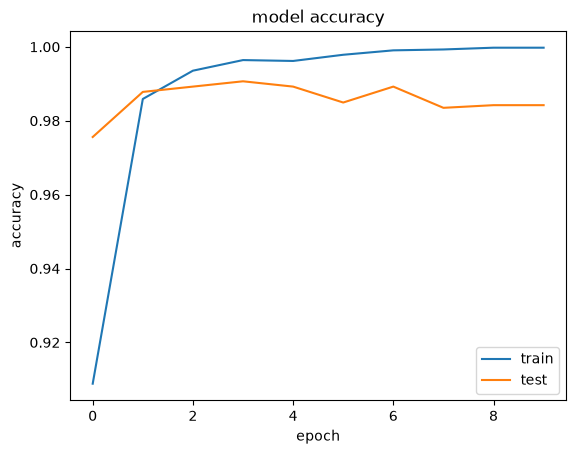

In [27]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    GRU(32),
    Dense(1, activation='sigmoid')
])
model.summary()

b. Compile your model

In [28]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 30, 32)         │       246,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,057 (988.50 KB)

 Trainable params: 253,057 (988.50 KB)

 Non-trainable params: 0 (0.00 B)

c. Train your model

In [29]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [30]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(m_history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 3s - 19ms/step - acc: 0.8758 - loss: 0.3533 - val_acc: 0.9706 - val_loss: 0.1557


Epoch 2/10


131/131 - 1s - 10ms/step - acc: 0.9811 - loss: 0.0665 - val_acc: 0.9864 - val_loss: 0.0467


Epoch 3/10


...

131/131 - 2s - 12ms/step - acc: 0.9986 - loss: 0.0045 - val_acc: 0.9871 - val_loss: 0.0744


Epoch 9/10


131/131 - 2s - 12ms/step - acc: 0.9998 - loss: 8.2865e-04 - val_acc: 0.9770 - val_loss: 0.1099


Epoch 10/10


131/131 - 1s - 11ms/step - acc: 1.0000 - loss: 3.7387e-04 - val_acc: 0.9871 - val_loss: 0.0835


The GRU ends at 98.1% (peak 98.9% at epoch 3) and overfits after a few epochs too. The three architectures end within 0.5 points of each other, about one standard error on 1393 test messages, so this run does not separate them. The task is easy because a few tokens (free, call, txt, prize) already indicate spam.

### Exercise 10
It's now time to try training our model using pretrained word embeddings.

a. First, get the pretrained word embeddings of your choice, you can get;

1. You can get Google word2vec from [here](https://code.google.com/archive/p/word2vec/), these embeddings are vectors of size 300
2. You can get Stanford's GloVe embeddings from [here](https://nlp.stanford.edu/projects/glove/), you are offered a choice between embedding vectors of sizes 40, 50, 100, 200 and 300

a. Use the Gensim library to load your embeddings

Feel free to use other libraries also.

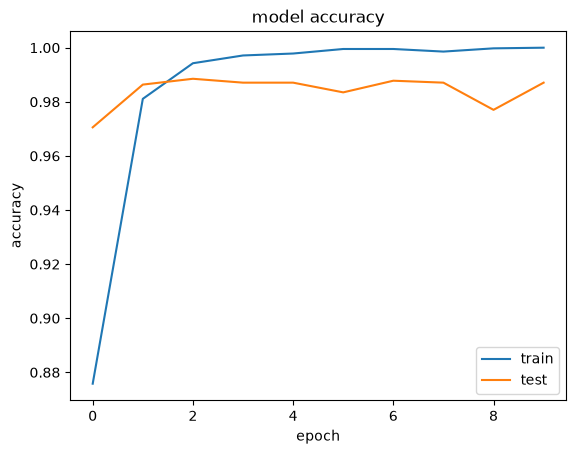

In [31]:
import gensim.downloader as api

print("Loading embeddings...")
word_vectors = api.load("glove-wiki-gigaword-50")
print("Embeddings loaded!")

b. If you work with embeddings of size 300 for example, then create a matrix **embeddings**. The shape of the matrix is (vocab_size, embedding_size=300). Each row corresponds to the embeddings of one word in your vocab.

In [32]:
import numpy as np
embedding_dim = 50
embedding_weights = np.zeros((vocab_size, embedding_dim))

for word, idx in tokenizer.word_index.items():
    if word in word_vectors:
        embedding_weights[idx] = word_vectors[word]

Loading embeddings...


Embeddings loaded!


c. Print the embedding_weights shape

In [33]:
print("Embedding weights shape:", embedding_weights.shape)

### Exercise 11
Let's now retrain our models, Simple RNN, LSTM and GRU using these embeddings.

Let's start by doing it for RNN again.

Define the architecture of your model again, show its summary, compile it and train it.

In [34]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              embeddings_initializer=tf.keras.initializers.Constant(embedding_weights),
              trainable=False),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])
model.summary()

Embedding weights shape: (7709, 50)


In [35]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 30, 50)         │       385,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         2,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,139 (1.48 MB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 385,450 (1.47 MB)

In [36]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [37]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 2s - 14ms/step - acc: 0.8971 - loss: 0.2713 - val_acc: 0.9318 - val_loss: 0.2024


Epoch 2/10


131/131 - 1s - 5ms/step - acc: 0.9567 - loss: 0.1315 - val_acc: 0.9447 - val_loss: 0.1833


Epoch 3/10


...

131/131 - 1s - 5ms/step - acc: 0.9777 - loss: 0.0764 - val_acc: 0.9720 - val_loss: 0.0901


Epoch 9/10


131/131 - 1s - 5ms/step - acc: 0.9794 - loss: 0.0686 - val_acc: 0.9749 - val_loss: 0.0887


Epoch 10/10


131/131 - 1s - 5ms/step - acc: 0.9823 - loss: 0.0647 - val_acc: 0.9698 - val_loss: 0.0959


### Exercise 12

Let's now retrain the model with LSTM architecture.

Define the architecture of your model again, show its summary, compile it and train it.

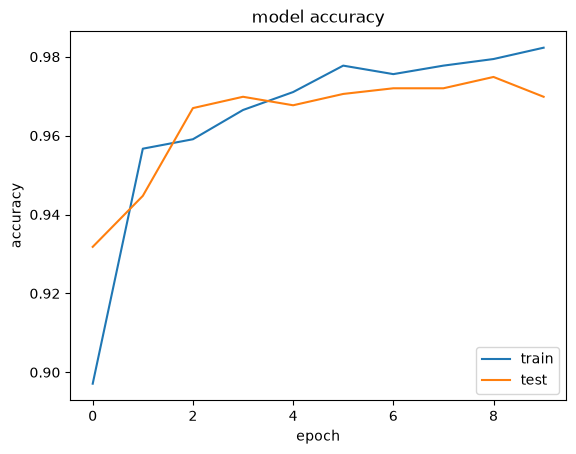

In [38]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              embeddings_initializer=tf.keras.initializers.Constant(embedding_weights),
              trainable=False),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
model.summary()

In [39]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 30, 50)         │       385,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 396,107 (1.51 MB)

 Trainable params: 10,657 (41.63 KB)

 Non-trainable params: 385,450 (1.47 MB)

In [40]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [41]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 2s - 17ms/step - acc: 0.9127 - loss: 0.2800 - val_acc: 0.9562 - val_loss: 0.1216


Epoch 2/10


131/131 - 1s - 8ms/step - acc: 0.9718 - loss: 0.0945 - val_acc: 0.9677 - val_loss: 0.0975


Epoch 3/10


...

131/131 - 1s - 8ms/step - acc: 0.9856 - loss: 0.0443 - val_acc: 0.9734 - val_loss: 0.0754


Epoch 9/10


131/131 - 1s - 8ms/step - acc: 0.9902 - loss: 0.0382 - val_acc: 0.9806 - val_loss: 0.0612


Epoch 10/10


131/131 - 1s - 8ms/step - acc: 0.9904 - loss: 0.0342 - val_acc: 0.9821 - val_loss: 0.0596


### Exercise 13

Let's now retrain the model with GRU architecture.

Define the architecture of your model again, show its summary, compile it and train it.

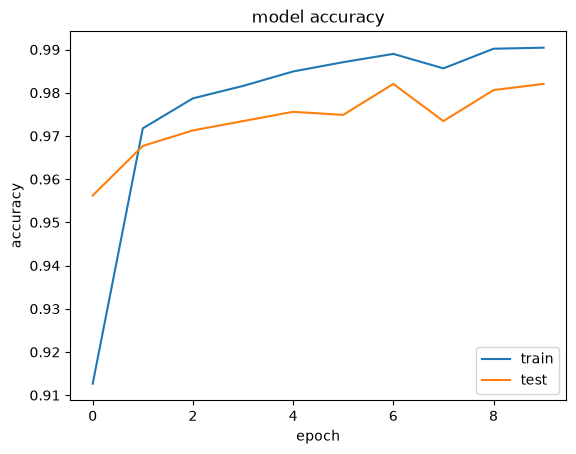

In [42]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim,
              embeddings_initializer=tf.keras.initializers.Constant(embedding_weights),
              trainable=False),
    GRU(32),
    Dense(1, activation='sigmoid')
])
model.summary()

In [43]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 30, 50)         │       385,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,547 (1.50 MB)

 Trainable params: 8,097 (31.63 KB)

 Non-trainable params: 385,450 (1.47 MB)

In [44]:
m_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)

In [45]:
# visualise training history
plt.plot(m_history.history['acc'])
plt.plot(model.history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

Epoch 1/10


131/131 - 2s - 19ms/step - acc: 0.9038 - loss: 0.3095 - val_acc: 0.9684 - val_loss: 0.1190


Epoch 2/10


131/131 - 1s - 9ms/step - acc: 0.9720 - loss: 0.0953 - val_acc: 0.9677 - val_loss: 0.0898


Epoch 3/10


...

131/131 - 1s - 10ms/step - acc: 0.9902 - loss: 0.0365 - val_acc: 0.9734 - val_loss: 0.0784


Epoch 9/10


131/131 - 1s - 10ms/step - acc: 0.9916 - loss: 0.0327 - val_acc: 0.9763 - val_loss: 0.0739


Epoch 10/10


131/131 - 1s - 11ms/step - acc: 0.9945 - loss: 0.0269 - val_acc: 0.9770 - val_loss: 0.0825


With frozen GloVe embeddings only the recurrent and output layers train (2.7k to 10k parameters instead of ~250k). Final test accuracies are RNN 97.3%, LSTM 98.2% and GRU 98.3%, with smoother curves and less overfitting. This is about the same accuracy as the learned embeddings, within one point. GloVe covers 97% of the tokens in the corpus, and the small gap to the learned embeddings comes from general-domain 50-d vectors that cannot adapt to SMS language. The LSTM and GRU end above the SimpleRNN in this setup.

## Regular Assignment
### Exercise 14

By now, hopefully the many-to-one RNN type makes sense. Let's now try a diffrent type, many-to-many.

We wish to build our own POS tagger. Recall how POS tags help us understand a first layer of the syntactic structure of a given sentence. 

There are various ways with which you can build a POS tagger. A rule-based one, a probabilistic one, using Hidden Markov Models (HMMs). There's also an option to build a statistical model to learn a POS tagger. 

We'll try the statistical approach. The training data is abundant, available through NLTK even.

We'll first acquire the TreeBank dataset.

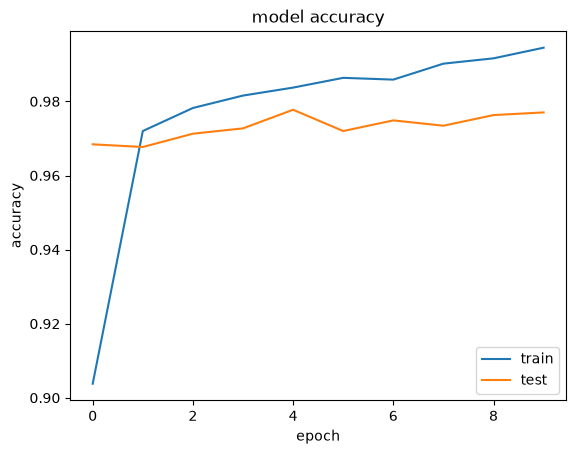

In [46]:
#You might need to download the dataset first
#nltk.download('treebank')

In [47]:
corpus = treebank.tagged_sents(tagset='universal')

Notice that each entry in the dataset is a tuple (word, pos_tag). We want our training **X** to have the words of the sentence, and **Y** to have the equivalent POS tags.

In [48]:
i=25
print(type(corpus[i]))
print(corpus[i])

a. Create your frame X which has all the sentences, and a frame Y with all the POS tags.

In [49]:
X = [[word for word, tag in sent] for sent in corpus]
Y = [[tag for word, tag in sent] for sent in corpus]

<class 'list'>
[('By', 'ADP'), ('1997', 'NUM'), (',', '.'), ('almost', 'ADV'), ('all', 'DET'), ('remaining', 'VERB'), ('uses', 'NOUN'), ('of', 'ADP'), ('cancer-causing', 'ADJ'), ('asbestos', 'NOUN'), ('will', 'VERB'), ('be', 'VERB'), ('outlawed', 'VERB'), ('*-6', 'X'), ('.', '.')]


In [50]:
i=0
print(X[i])
print(Y[i])

### Exercise 15

Check that you have the same number of entries in X and Y.

Check also that every entry in X, has the same number of elements as in its equivalent of Y.

If a sentence in X has 5 tokens, we need to have 5 POS tags in Y.

In [51]:
assert len(X) == len(Y)
assert all(len(x) == len(y) for x, y in zip(X, Y))
print("Sentences:", len(X), "| all sentences have as many tags as tokens")

['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.']


3914 sentences is enough training data for our model.

### Exercise 16

a. Let's now move on to convert X and Y both to integers, using Keras's tokenizer.

In [52]:
# no filters: punctuation tokens and the '.' tag would otherwise be dropped
x_tokenizer = Tokenizer(filters='', oov_token='<OOV>')
x_tokenizer.fit_on_texts(X)
X_encoded = x_tokenizer.texts_to_sequences(X)

y_tokenizer = Tokenizer(filters='', lower=False)
y_tokenizer.fit_on_texts(Y)
Y_encoded = y_tokenizer.texts_to_sequences(Y)

Sentences: 3914 | all sentences have as many tags as tokens


a. Let's print the size of the vocab, also the number of different POS tags we have.

We need to know how many different POS tags we have, because that should be our number of classes.

In [53]:
vocab_size = len(x_tokenizer.word_index) + 1
n_tags = len(y_tokenizer.word_index) + 1
print("Vocab size:", vocab_size)
print("Number of POS tags:", n_tags - 1, "(+1 for the padding index 0)")
print(y_tokenizer.word_index)

### Exercise 17

Let's again pad our sentences and our tags. We, again, need to decide on our max length, a decision that is crucial as this matches the number of time steps for our RNN architecture

In [54]:
lengths = [len(s) for s in X_encoded]
print("Longest sentence:", max(lengths), "| mean:", np.mean(lengths))
print("Share of sentences with at most 100 tokens:", np.mean(np.array(lengths) <= 100))

max_len = 100
X_padded = pad_sequences(X_encoded, maxlen=max_len, padding='post', truncating='post')
Y_padded = pad_sequences(Y_encoded, maxlen=max_len, padding='post', truncating='post')

Vocab size: 11389
Number of POS tags: 12 (+1 for the padding index 0)
{'NOUN': 1, 'VERB': 2, '.': 3, 'ADP': 4, 'DET': 5, 'X': 6, 'ADJ': 7, 'NUM': 8, 'PRT': 9, 'ADV': 10, 'PRON': 11, 'CONJ': 12}


In [55]:
i=0
print(X_padded[i])
print(Y_padded[i])


Longest sentence: 271 | mean: 25.722023505365357
Share of sentences with at most 100 tokens: 0.9989780275932549


### Exercise 18

Try a first version of your RNN models without using any pretrained embeddings.


a. Let's one-hot encode Y

In [56]:
Y = to_categorical(Y_padded, num_classes=n_tags)
print(Y.shape)

[5602 3747    2 2025   87  332    2   47 2406    3  132   28    7 2026
  333  460 2027    4    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
[1 1 3 8 1 7 3 2 2 5 1 4 5 7 1 1 8 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


b. We create a train and test set.

In [57]:
# split entire data into training and testing sets
TEST_SIZE = 0.20
X_train, X_test, y_train, y_test = train_test_split(X_padded, Y, test_size=TEST_SIZE, random_state=100)

(3914, 100, 13)


c. Define your RNN model, using a simple RNN. Compile it and fit it to the data.

Do not forget to wrap your Dense output layer with the TimeDistributed wrapper. We're doing a multiclassification at each time step.

In [58]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
    SimpleRNN(64, return_sequences=True),
    TimeDistributed(Dense(n_tags, activation='softmax'))
])
model.summary()

In [59]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 64)        │       728,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737,997 (2.82 MB)

 Trainable params: 737,997 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
rnn_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)
rnn_model = model

### Exercise 19
Retrain the model with an LSTM. 
This should work faster, and yield better results.
Define, compile and fit your model.

In [61]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(n_tags, activation='softmax'))
])
model.summary()

Epoch 1/10


E0000 00:00:1790704443.733152 4093226 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


98/98 - 8s - 80ms/step - acc: 0.5228 - loss: 1.6602 - val_acc: 0.7696 - val_loss: 0.9293


Epoch 2/10


98/98 - 4s - 39ms/step - acc: 0.8469 - loss: 0.5817 - val_acc: 0.8987 - val_loss: 0.3836


...

98/98 - 4s - 36ms/step - acc: 0.9897 - loss: 0.0400 - val_acc: 0.9492 - val_loss: 0.1647


Epoch 9/10


98/98 - 4s - 40ms/step - acc: 0.9920 - loss: 0.0322 - val_acc: 0.9458 - val_loss: 0.1722


Epoch 10/10


98/98 - 4s - 41ms/step - acc: 0.9938 - loss: 0.0254 - val_acc: 0.9452 - val_loss: 0.1782


In [62]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 64)        │       728,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 762,765 (2.91 MB)

 Trainable params: 762,765 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
lstm_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)
lstm_model = model

### Exercise 20
Retrain the model with a GRU. 

In [64]:
model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=64, mask_zero=True),
    GRU(64, return_sequences=True),
    TimeDistributed(Dense(n_tags, activation='softmax'))
])
model.summary()

Epoch 1/10


98/98 - 9s - 94ms/step - acc: 0.4267 - loss: 1.9412 - val_acc: 0.6969 - val_loss: 1.1848


Epoch 2/10


98/98 - 7s - 68ms/step - acc: 0.8062 - loss: 0.7102 - val_acc: 0.8870 - val_loss: 0.4422


Epoch 3/10


...

98/98 - 5s - 53ms/step - acc: 0.9832 - loss: 0.0583 - val_acc: 0.9423 - val_loss: 0.1743


Epoch 9/10


98/98 - 5s - 55ms/step - acc: 0.9841 - loss: 0.0519 - val_acc: 0.9435 - val_loss: 0.1740


Epoch 10/10


98/98 - 5s - 55ms/step - acc: 0.9861 - loss: 0.0459 - val_acc: 0.9445 - val_loss: 0.1751


In [65]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 64)        │       728,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100, 64)        │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 754,701 (2.88 MB)

 Trainable params: 754,701 (2.88 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
gru_history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), verbose=2)
gru_model = model

All three models reach about 94.7-94.8% test accuracy, computed with the padding positions masked, and the GRU is marginally the best. The differences are negligible. Accuracy is 97.2% on test tokens that occur in the training set and 63% on the 6.9% of test tokens that never occur in it. The tokenizer was fitted on the whole corpus, so those words have an index but an embedding that was never trained. This accounts for about half of the errors. All models overfit after about epoch 7 (test loss rises).

### Exercise 21
Save one of your models (the one with the best performance) as an h5 file. This is a straightforward operation, refer to [here](https://keras.io/api/models/model_saving_apis/).

You will use it on the **Advanced** part of the assignment to make inferences.

In [68]:
import json
from pathlib import Path

models = {"rnn": rnn_model, "lstm": lstm_model, "gru": gru_model}
val_acc = {name: m.evaluate(X_test, y_test, verbose=0)[1] for name, m in models.items()}
print(val_acc)

best = max(val_acc, key=val_acc.get)
print("Best model:", best)

out_dir = Path.cwd() / "lab-1-dt-adv" / "models"
out_dir.mkdir(exist_ok=True)
models[best].save(out_dir / "pos_tagger.h5")

# the inference notebook needs the same token/tag indices
(out_dir / "x_tokenizer.json").write_text(x_tokenizer.to_json())
(out_dir / "y_tokenizer.json").write_text(y_tokenizer.to_json())

Epoch 1/10


98/98 - 9s - 94ms/step - acc: 0.5565 - loss: 1.6122 - val_acc: 0.7855 - val_loss: 0.7694


Epoch 2/10


98/98 - 5s - 52ms/step - acc: 0.8730 - loss: 0.4560 - val_acc: 0.9209 - val_loss: 0.2984


Epoch 3/10


...

98/98 - 5s - 56ms/step - acc: 0.9835 - loss: 0.0482 - val_acc: 0.9492 - val_loss: 0.1600


Epoch 10/10


98/98 - 5s - 56ms/step - acc: 0.9846 - loss: 0.0446 - val_acc: 0.9483 - val_loss: 0.1623


{'rnn': 0.9451680779457092, 'lstm': 0.9444639682769775, 'gru': 0.9482870101928711}
Best model: gru


1121